In [1]:
import os
import io
import zipfile
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
def calc_filtered_mid(df, threshold=15):
    """
    Calculates a filtered mid-price, safely ignoring NaN values 
    in the order book data.
    """
    # 1. Extract Arrays
    b_px = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].values
    b_vol = df[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].values
    a_px = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].values
    a_vol = df[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].values

    # 2. Safely handle volume NaNs (treat missing volume as 0)
    b_vol_safe = np.nan_to_num(b_vol, nan=0.0)
    a_vol_safe = np.nan_to_num(a_vol, nan=0.0)

    b_mask = b_vol_safe >= threshold
    a_mask = a_vol_safe >= threshold

    # 3. Process Bids
    valid_b_px = np.where(b_mask, b_px, -np.inf)
    # Use nanmax to ignore NaNs in the price columns
    best_b_px_filtered = np.nanmax(valid_b_px, axis=1)
    
    fallback_b_idx = np.argmax(b_vol_safe, axis=1)
    fallback_b_px = b_px[np.arange(len(b_px)), fallback_b_idx]
    
    final_bid = np.where(np.any(b_mask, axis=1), best_b_px_filtered, fallback_b_px)

    # 4. Process Asks
    valid_a_px = np.where(a_mask, a_px, np.inf)
    # Use nanmin to ignore NaNs in the price columns
    best_a_px_filtered = np.nanmin(valid_a_px, axis=1)
    
    fallback_a_idx = np.argmax(a_vol_safe, axis=1)
    fallback_a_px = a_px[np.arange(len(a_px)), fallback_a_idx]
    
    final_ask = np.where(np.any(a_mask, axis=1), best_a_px_filtered, fallback_a_px)

    # 5. Calculate the filtered mid price
    filtered_mid = (final_bid + final_ask) / 2
    filtered_mid = pd.Series(filtered_mid).ffill()

    return filtered_mid

In [3]:
price = pd.read_csv('../data/raw/round_3/prices_round_3_day_0.csv', delimiter=';').drop(columns=['profit_and_loss'])
products = sorted(list(price['product'].unique()))
strikes = [int(x[4:]) for x in products if x[:3] == 'VEV']

price_hydro = price[price['product'] == 'HYDROGEL_PACK'].reset_index(drop=True)
price_velvet = price[price['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)

price_vev = {}
for s in strikes:
    price_vev[s] = price[price['product'] == f'VEV_{s}'].reset_index(drop=True)

In [4]:
price_1 = pd.read_csv('../data/raw/round_3/prices_round_3_day_1.csv', delimiter=';').drop(columns=['profit_and_loss'])

price_hydro_1 = price_1[price_1['product'] == 'HYDROGEL_PACK'].reset_index(drop=True)
price_velvet_1 = price_1[price_1['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)

price_vev_1 = {}
for s in strikes:
    price_vev_1[s] = price_1[price_1['product'] == f'VEV_{s}'].reset_index(drop=True)

In [5]:
price_2 = pd.read_csv('../data/raw/round_3/prices_round_3_day_2.csv', delimiter=';').drop(columns=['profit_and_loss'])

price_hydro_2 = price_2[price_2['product'] == 'HYDROGEL_PACK'].reset_index(drop=True)
price_velvet_2 = price_2[price_2['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)

price_vev_2 = {}
for s in strikes:
    price_vev_2[s] = price_2[price_2['product'] == f'VEV_{s}'].reset_index(drop=True)

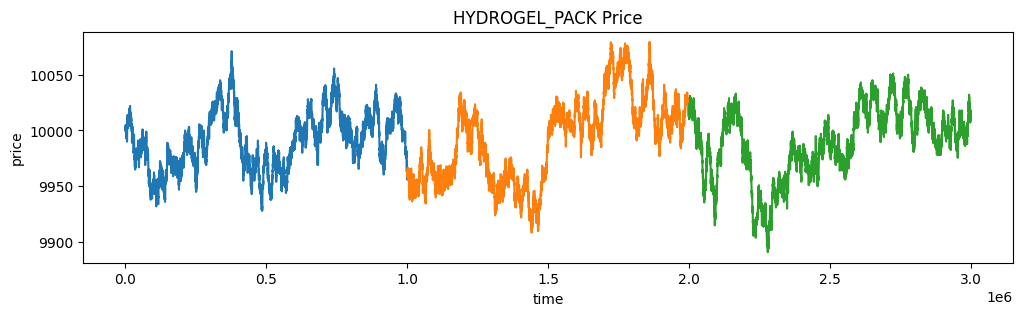

In [6]:
plt.figure(figsize=(12, 3))
plt.plot(price_hydro['timestamp'], price_hydro['mid_price'])
plt.plot(price_hydro_1['timestamp'] + 1000000, price_hydro_1['mid_price'])
plt.plot(price_hydro_2['timestamp'] + 2000000, price_hydro_2['mid_price'])
plt.title('HYDROGEL_PACK Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

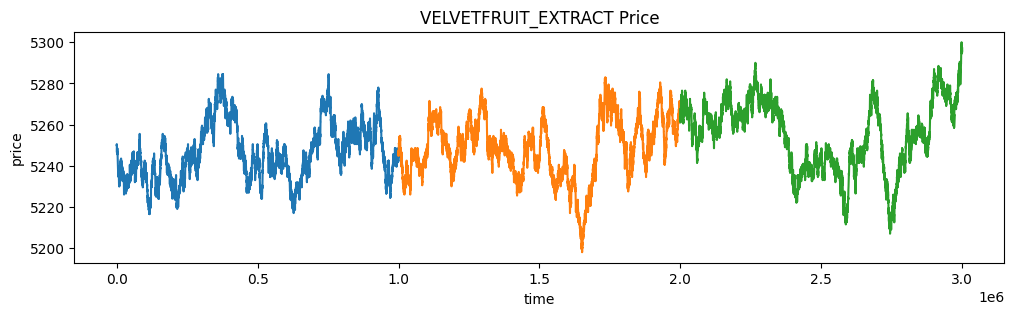

In [7]:
plt.figure(figsize=(12, 3))
plt.plot(price_velvet['timestamp'], price_velvet['mid_price'])
plt.plot(price_velvet_1['timestamp'] + 1000000, price_velvet_1['mid_price'])
plt.plot(price_velvet_2['timestamp'] + 2000000, price_velvet_2['mid_price'])
plt.title('VELVETFRUIT_EXTRACT Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

# HYDROGEL_PACK

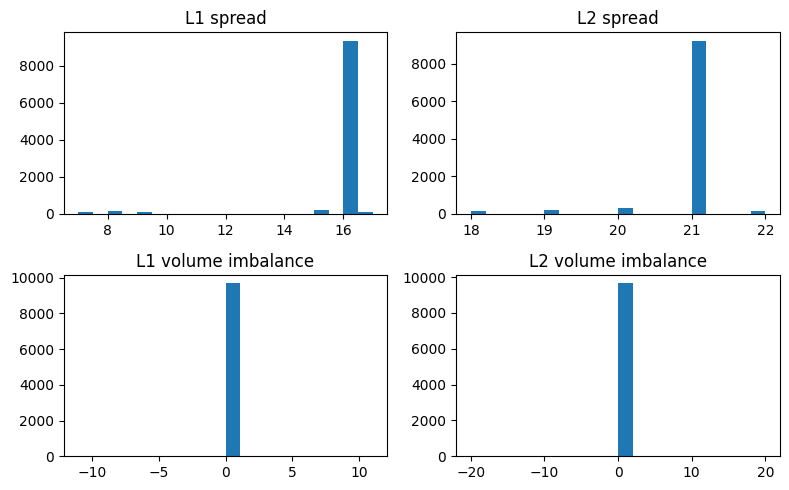

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0, 0].hist(price_hydro['ask_price_1'] - price_hydro['bid_price_1'], bins=20)
ax[0, 1].hist(price_hydro['ask_price_2'] - price_hydro['bid_price_2'], bins=20)
ax[1, 0].hist(price_hydro['ask_volume_1'] - price_hydro['bid_volume_1'], bins=20)
ax[1, 1].hist(price_hydro['ask_volume_2'] - price_hydro['bid_volume_2'], bins=20)
ax[0, 0].set_title('L1 spread')
ax[0, 1].set_title('L2 spread')
ax[1, 0].set_title('L1 volume imbalance')
ax[1, 1].set_title('L2 volume imbalance')
plt.tight_layout()
plt.show()

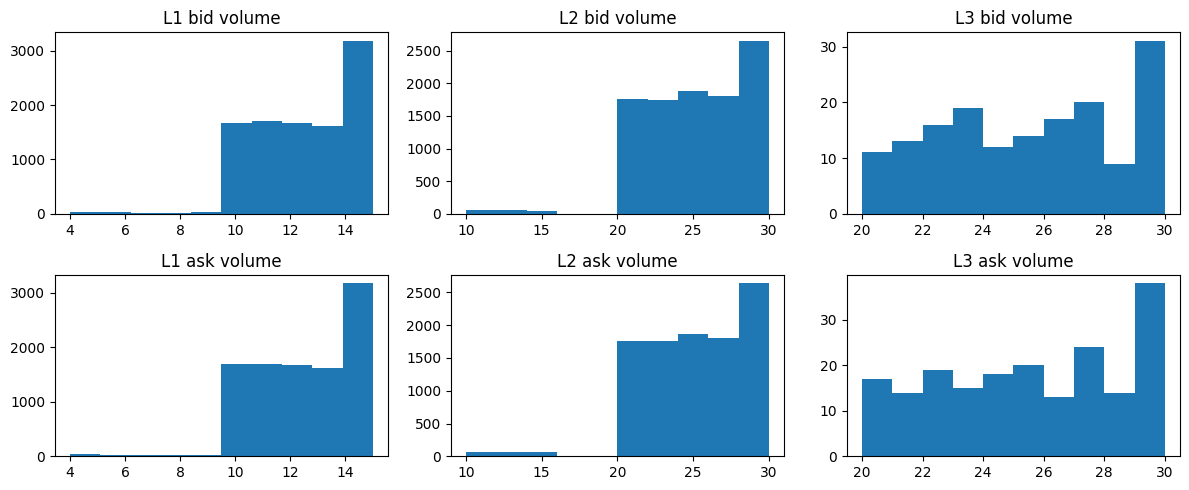

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0, 0].hist(price_hydro['bid_volume_1'])
ax[0, 1].hist(price_hydro['bid_volume_2'])
ax[0, 2].hist(price_hydro['bid_volume_3'])
ax[1, 0].hist(price_hydro['ask_volume_1'])
ax[1, 1].hist(price_hydro['ask_volume_2'])
ax[1, 2].hist(price_hydro['ask_volume_3'])
ax[0, 0].set_title('L1 bid volume')
ax[0, 1].set_title('L2 bid volume')
ax[0, 2].set_title('L3 bid volume')
ax[1, 0].set_title('L1 ask volume')
ax[1, 1].set_title('L2 ask volume')
ax[1, 2].set_title('L3 ask volume')
plt.tight_layout()
plt.show()

In [10]:
price_hydro = price_hydro.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=20))
price_hydro_1 = price_hydro_1.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=20))
price_hydro_2 = price_hydro_2.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=20))

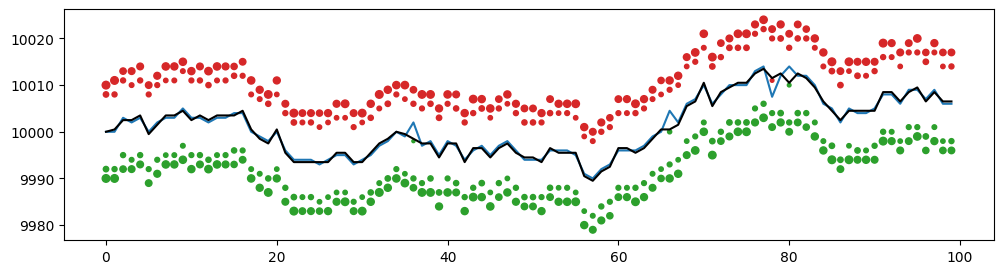

In [11]:
l = 100
plt.figure(figsize=(12, 3))
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['bid_price_1'], s=price_hydro.iloc[:l]['bid_volume_1'], c='tab:green')
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['bid_price_2'], s=price_hydro.iloc[:l]['bid_volume_2'], c='tab:green')
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['bid_price_3'], s=price_hydro.iloc[:l]['bid_volume_3'], c='tab:green')
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['ask_price_1'], s=price_hydro.iloc[:l]['ask_volume_1'], c='tab:red')
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['ask_price_2'], s=price_hydro.iloc[:l]['ask_volume_2'], c='tab:red')
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['ask_price_3'], s=price_hydro.iloc[:l]['ask_volume_3'], c='tab:red')
plt.plot(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['mid_price'])
plt.plot(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['filtered_mid'], c='k')
plt.show()

In [12]:
print(price_hydro['filtered_mid'].mean(), price_hydro_1['filtered_mid'].mean(), price_hydro_2['filtered_mid'].mean())
print(pd.concat([price_hydro['filtered_mid'], price_hydro_1['filtered_mid'], price_hydro_2['filtered_mid']]).reset_index(drop=True).mean())
print(price_hydro['filtered_mid'].std(), price_hydro_1['filtered_mid'].std(), price_hydro_2['filtered_mid'].std())
print(pd.concat([price_hydro['filtered_mid'], price_hydro_1['filtered_mid'], price_hydro_2['filtered_mid']]).reset_index(drop=True).std())

9990.9849 9992.05485 9989.4178
9990.819183333333
25.313481570596377 37.61448193718265 31.62954213948718
31.934120309386742


In [13]:
hydro_mean = 9990
hydro_std = 32

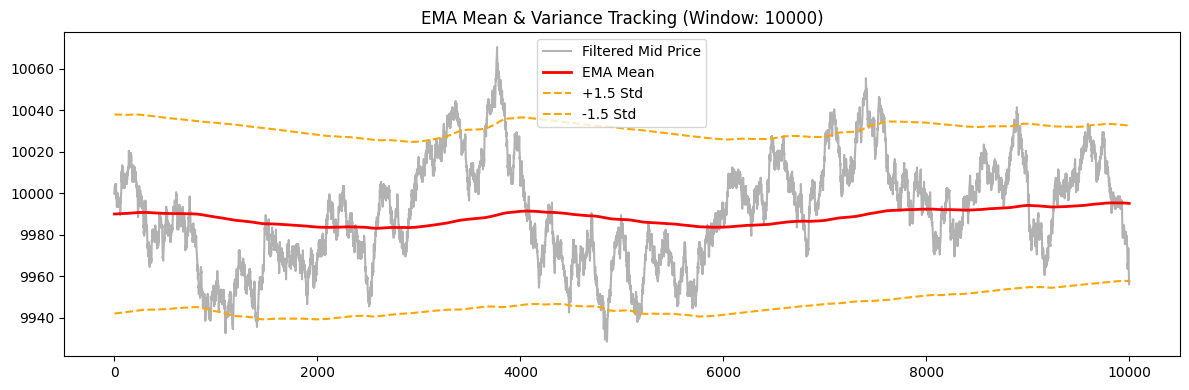

In [17]:
price_df = price_hydro

# 1. Initial States (Historical Hardcoded Values)
ema_mean = 9990.0
ema_var = 32.0 ** 2

# 2. The Tuning Parameter (Equivalent to Q in the Kalman Filter)
# A smaller window adapts faster to regime shifts but is noisier.
# A larger window is more stubborn but slower to catch up to big moves.
window_size = 10000
alpha = 2 / (window_size + 1)

estimated_means = []
estimated_stds = []

# 3. EMA Updating Loop
for price in price_df['filtered_mid']:
    # Calculate difference from the *old* mean
    diff = price - ema_mean
    
    # Update Variance FIRST (Mathematically requires the difference from the old mean)
    ema_var = (1 - alpha) * ema_var + alpha * (diff ** 2)
    
    # Update Mean SECOND
    ema_mean = ema_mean + (alpha * diff)
    
    # Calculate instantaneous dynamic standard deviation
    current_std = math.sqrt(ema_var)
    
    estimated_means.append(ema_mean)
    estimated_stds.append(current_std)

# 4. Save to DataFrame
price_df['estimated_mean'] = estimated_means
price_df['estimated_std'] = estimated_stds

# 5. Plotting (With your exact 1.5 Std Dev bands)
plt.figure(figsize=(12, 4))
plt.plot(price_df['filtered_mid'], label='Filtered Mid Price', color='gray', alpha=0.6)
plt.plot(price_df['estimated_mean'], label='EMA Mean', color='red', linewidth=2)
plt.plot(price_df['estimated_mean'] + 1.5 * price_df['estimated_std'], color='orange', linestyle='--', label='+1.5 Std')
plt.plot(price_df['estimated_mean'] - 1.5 * price_df['estimated_std'], color='orange', linestyle='--', label='-1.5 Std')

plt.title(f'EMA Mean & Variance Tracking (Window: {window_size})')
plt.legend()
plt.tight_layout()
plt.show()

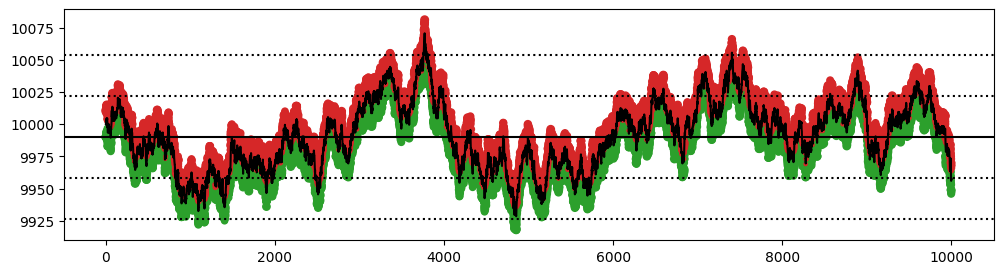

In [42]:
plt.figure(figsize=(12, 3))
plt.scatter(price_hydro['timestamp']//100, price_hydro['bid_price_1'], s=price_hydro['bid_volume_1'], c='tab:green')
plt.scatter(price_hydro['timestamp']//100, price_hydro['bid_price_2'], s=price_hydro['bid_volume_2'], c='tab:green')
plt.scatter(price_hydro['timestamp']//100, price_hydro['bid_price_3'], s=price_hydro['bid_volume_3'], c='tab:green')
plt.scatter(price_hydro['timestamp']//100, price_hydro['ask_price_1'], s=price_hydro['ask_volume_1'], c='tab:red')
plt.scatter(price_hydro['timestamp']//100, price_hydro['ask_price_2'], s=price_hydro['ask_volume_2'], c='tab:red')
plt.scatter(price_hydro['timestamp']//100, price_hydro['ask_price_3'], s=price_hydro['ask_volume_3'], c='tab:red')
plt.plot(price_hydro['timestamp']//100, price_hydro['filtered_mid'], c='k')
plt.axhline(hydro_mean, c='k')
plt.axhline(hydro_mean + 1 * hydro_std, c='k', linestyle='dotted')
plt.axhline(hydro_mean - 1 * hydro_std, c='k', linestyle='dotted')
plt.axhline(hydro_mean + 2 * hydro_std, c='k', linestyle='dotted')
plt.axhline(hydro_mean - 2 * hydro_std, c='k', linestyle='dotted')
plt.show()

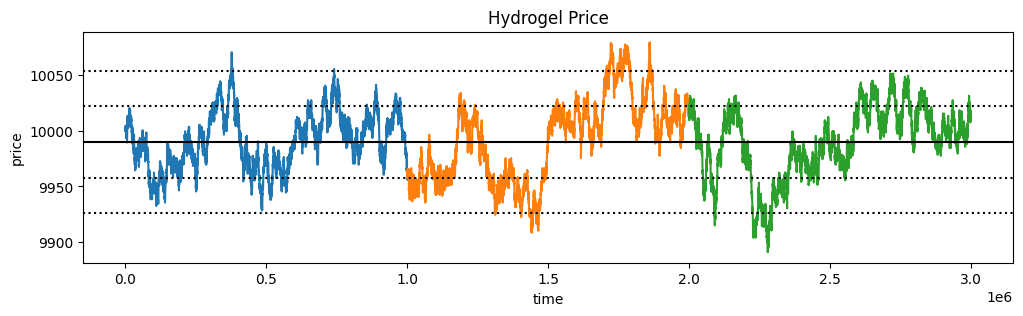

In [109]:
plt.figure(figsize=(12, 3))
plt.plot(price_hydro['timestamp'], price_hydro['filtered_mid'])
plt.plot(price_hydro_1['timestamp'] + 1000000, price_hydro_1['filtered_mid'])
plt.plot(price_hydro_2['timestamp'] + 2000000, price_hydro_2['filtered_mid'])
plt.axhline(hydro_mean, c='k')
plt.axhline(hydro_mean + 1 * hydro_std, c='k', linestyle='dotted')
plt.axhline(hydro_mean - 1 * hydro_std, c='k', linestyle='dotted')
plt.axhline(hydro_mean + 2 * hydro_std, c='k', linestyle='dotted')
plt.axhline(hydro_mean - 2 * hydro_std, c='k', linestyle='dotted')
plt.title('Hydrogel Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

In [93]:
imbalance = (price_hydro.fillna(0)['bid_volume_2'] + price_hydro.fillna(0)['bid_volume_3']) / \
    (price_hydro.fillna(0)['bid_volume_2'] + price_hydro.fillna(0)['bid_volume_3'] + \
     price_hydro.fillna(0)['ask_volume_2'] + price_hydro.fillna(0)['ask_volume_3'])
price_hydro = price_hydro.assign(imbalance=imbalance)

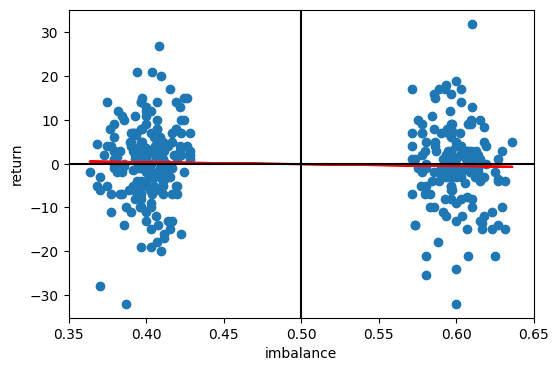

In [94]:
y = price_hydro[(price_hydro['imbalance'] > 0.5) | (price_hydro['imbalance'] < 0.5)]['filtered_mid'].diff(periods=1).dropna()
x = price_hydro[(price_hydro['imbalance'] > 0.5) | (price_hydro['imbalance'] < 0.5)]['imbalance'].iloc[-len(y):]
m, c = np.polyfit(x, y, 1)

plt.figure(figsize=(6, 4))
plt.scatter(x, y)
plt.plot(x, m * x + c, c='r')
plt.axhline(0, c='k')
plt.axvline(0.5, c='k')
plt.xlabel('imbalance')
plt.ylabel('return')
plt.show()

In [80]:
train_logr = np.log(price_hydro['filtered_mid']).diff().dropna()
test_logr = np.log(price_hydro_1['filtered_mid']).diff().dropna()

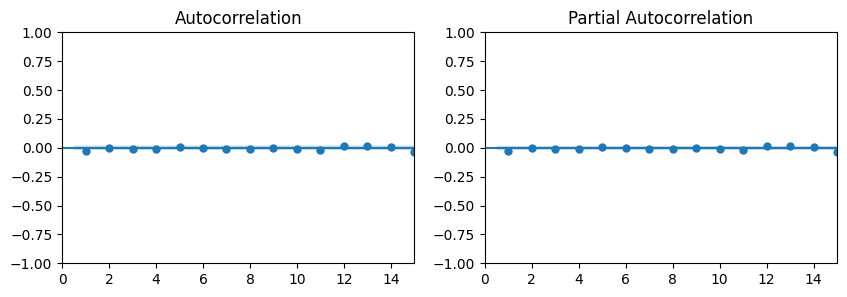

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(train_logr, ax=ax[0], zero=False)
plot_pacf(train_logr, ax=ax[1], zero=False)
ax[0].set_xlim([0, 15])
ax[1].set_xlim([0, 15])
plt.show()

In [82]:
# Perform Ljung-Box test for lags up to 10
result = acorr_ljungbox(train_logr, lags=[10], return_df=True)
print(result)

# Interpretation
if result['lb_pvalue'].values[0] > 0.05:
    print("Fail to reject null hypothesis: data may be white noise.")
else:
    print("Reject null hypothesis: data is not white noise.")

      lb_stat  lb_pvalue
10  13.720109   0.186145
Fail to reject null hypothesis: data may be white noise.


In [104]:
true = test_logr[1:].to_numpy()

In [105]:
# Naive
pred = test_logr[:-1].to_numpy()
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'Naive RMSE: {rmse}')

Naive RMSE: 0.0002712888903066747


In [108]:
# AR(1)
coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
a, b = coeffs
print(f'Params: a = {round(a, 2)}, b = {round(b, 2)}')

pred = test_logr[:-1].to_numpy() * a
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'AR(1) RMSE: {rmse}')

Params: a = -0.03, b = -0.0
AR(1) RMSE: 0.00019028811313734603
